# 05 · Ponto de corte e simulação financeira

Um modelo de crédito não decide nada sozinho. Ele entrega uma probabilidade de default, e alguém precisa escolher a partir de qual probabilidade a proposta é recusada. Muita gente usa 0,50 sem pensar, porque é o padrão do `predict()`. Só que isso não tem nenhuma relação com a economia do negócio.

A pergunta certa é: **com qual ponto de corte a cooperativa ganha mais dinheiro?** Aprovar um bom pagador gera margem, aprovar um inadimplente gera prejuízo, e recusar alguém não gera nenhum dos dois. O melhor cutoff é o que equilibra essas duas coisas.

Neste notebook eu uso as probabilidades do LightGBM (e do scorecard, para comparar) na base de **validação**. A confirmação final dos números fica para a base de teste, no último notebook.

In [1]:
import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from credit_scoring.cutoff import ProfitAssumptions, optimal, profit_curve, simulate
from credit_scoring.data import PROCESSED_DIR, ROOT, TARGET
from credit_scoring.features import FEATURES
from credit_scoring.plotting import BLUE, GRAY, ORANGE, savefig, set_style
from credit_scoring.reporting import brl, update_metrics
from credit_scoring.scorecard import SCORECARD_FEATURES, proba_to_score

set_style()
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

val = pd.read_parquet(PROCESSED_DIR / "val.parquet")
y_val = val[TARGET].values
p_gbm = lgb.Booster(model_file=str(ROOT / "models" / "lightgbm.txt")).predict(val[FEATURES])
p_scorecard = joblib.load(ROOT / "models" / "logistic_woe.joblib").predict_proba(val[SCORECARD_FEATURES])[:, 1]
print(f"{len(val):,} propostas na validação")

22,500 propostas na validação


## 1. As premissas

A base do Kaggle não traz valor de empréstimo, taxa de juros nem recuperação. Então as premissas abaixo são **ilustrativas**, escolhidas para serem plausíveis para um empréstimo pessoal numa cooperativa. Elas ficam todas em `ProfitAssumptions` (em `src/credit_scoring/cutoff.py`), e basta trocar os valores para refazer a análise com os números reais de uma instituição.

- **Ticket:** R$ 10 mil por empréstimo.
- **Margem de um bom pagador:** 15% do ticket ao longo do contrato, já descontados custo de captação, custo operacional e impostos.
- **Perda de um inadimplente:** em média, 80% do valor ainda está em aberto quando o atraso acontece (EAD), e 60% disso não é recuperado na cobrança (LGD).

In [2]:
assumptions = ProfitAssumptions()
pd.Series({
    "ticket": brl(assumptions.ticket),
    "ganho com um bom pagador": brl(assumptions.gain_good),
    "perda com um inadimplente": brl(assumptions.loss_bad),
    "perda / ganho": f"{assumptions.loss_bad / assumptions.gain_good:.1f}x",
    "PD de equilíbrio": f"{assumptions.breakeven_pd:.1%}",
}, name="valor").to_frame()

,valor
ticket,R$ 10.000
ganho com um bom pagador,R$ 1.500
perda com um inadimplente,R$ 4.800
perda / ganho,3.2x
PD de equilíbrio,23.8%


Um inadimplente custa bem mais do que um bom pagador rende, então é preciso vários bons pagadores para cobrir cada default.

A última linha é a chave de tudo. Aprovar uma proposta com probabilidade de default *p* dá, em média, $(1-p) \times \text{ganho} - p \times \text{perda}$. Isso é positivo enquanto

$$p < \frac{\text{ganho}}{\text{ganho} + \text{perda}}$$

Então, **se as probabilidades do modelo forem confiáveis**, o cutoff ótimo é essa PD de equilíbrio, e não 0,50. Aprovar alguém com 30% de chance de default, como o cutoff de 0,50 faz, é perder dinheiro em média.

## 2. A curva de lucro

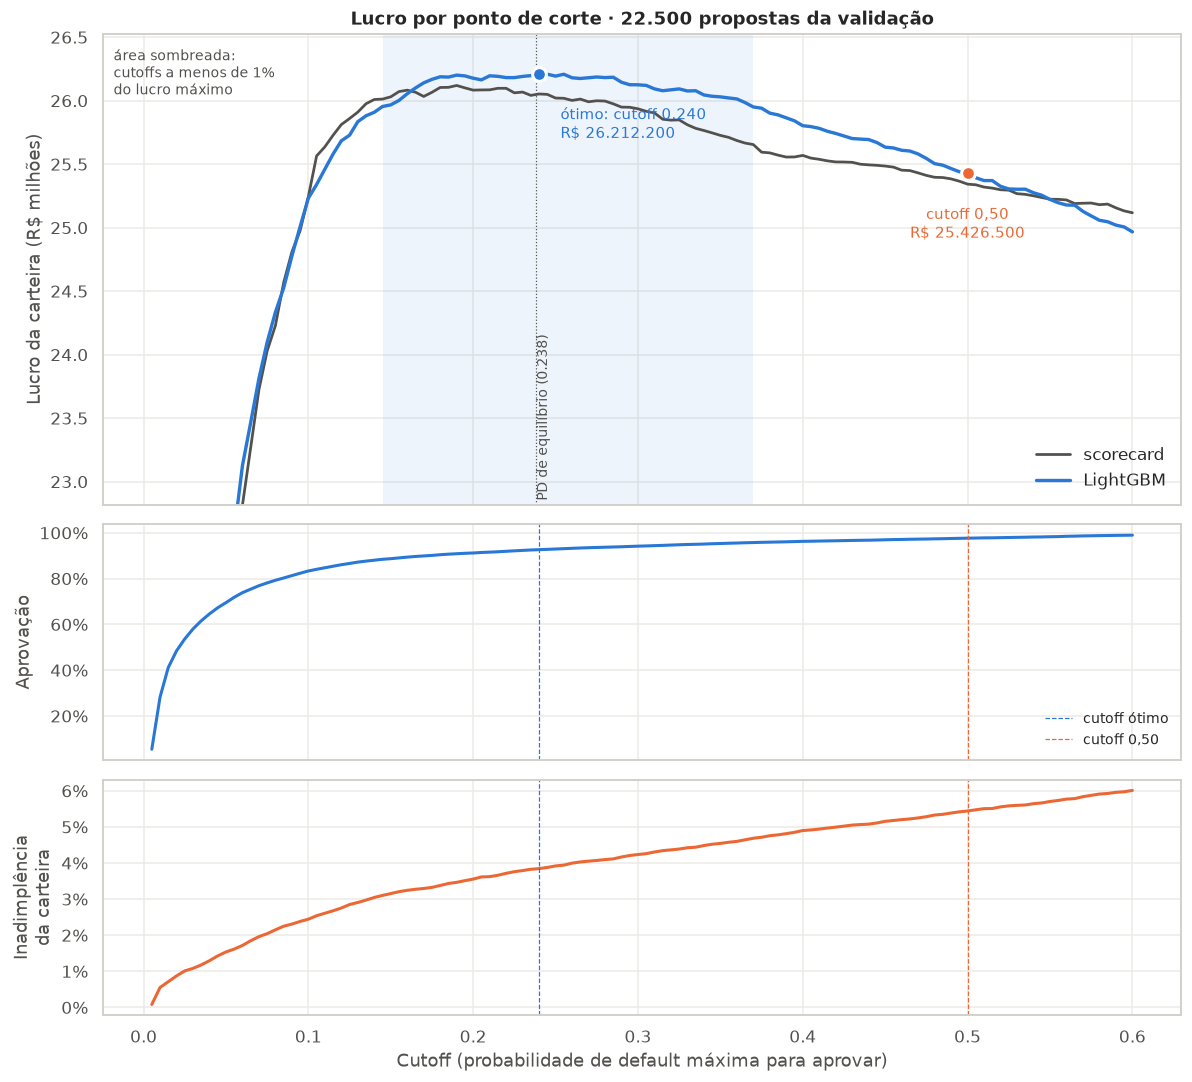

In [3]:
curve_gbm = profit_curve(y_val, p_gbm, assumptions)
curve_sc = profit_curve(y_val, p_scorecard, assumptions)
best_gbm, best_sc = optimal(curve_gbm), optimal(curve_sc)

naive = simulate(y_val, p_gbm, 0.5, assumptions)
approve_all = simulate(y_val, p_gbm, 1.0, assumptions)
near_best = curve_gbm[curve_gbm["lucro"] >= 0.99 * best_gbm["lucro"]]["cutoff"]

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True, gridspec_kw={"height_ratios": [2, 1, 1]})
ax = axes[0]
ax.axvspan(near_best.min(), near_best.max(), color=BLUE, alpha=0.08, lw=0)
ax.plot(curve_sc["cutoff"], curve_sc["lucro"] / 1e6, color=GRAY, lw=1.8, label="scorecard")
ax.plot(curve_gbm["cutoff"], curve_gbm["lucro"] / 1e6, color=BLUE, lw=2.2, label="LightGBM")
# eixo y recortado perto do máximo: é ali que as políticas se diferenciam
y_top = best_gbm["lucro"] / 1e6
ax.set_ylim(approve_all["lucro"] / 1e6 * 0.94, y_top * 1.012)
ax.axvline(assumptions.breakeven_pd, color=GRAY, lw=0.8, ls=":")
ax.text(assumptions.breakeven_pd, ax.get_ylim()[0], f" PD de equilíbrio ({assumptions.breakeven_pd:.3f})",
        color=GRAY, fontsize=9, va="bottom", rotation=90)
ax.plot(best_gbm["cutoff"], y_top, "o", color=BLUE, ms=9, mec="white", mew=2)
ax.annotate(f"ótimo: cutoff {best_gbm['cutoff']:.3f}\n{brl(best_gbm['lucro'])}", (best_gbm["cutoff"], y_top),
            xytext=(14, -42), textcoords="offset points", color=BLUE, fontsize=10)
ax.plot(0.5, naive["lucro"] / 1e6, "o", color=ORANGE, ms=9, mec="white", mew=2)
ax.annotate(f"cutoff 0,50\n{brl(naive['lucro'])}", (0.5, naive["lucro"] / 1e6),
            xytext=(0, -42), textcoords="offset points", color=ORANGE, fontsize=10, ha="center")
ax.set_ylabel("Lucro da carteira (R$ milhões)")
ax.set_title(f"Lucro por ponto de corte · {len(val):,} propostas da validação".replace(",", "."))
ax.legend(loc="lower right", frameon=False)
ax.text(0.01, 0.97, "área sombreada:\ncutoffs a menos de 1%\ndo lucro máximo", transform=ax.transAxes, va="top",
        color=GRAY, fontsize=9)

axes[1].plot(curve_gbm["cutoff"], curve_gbm["aprovação"], color=BLUE, lw=2)
axes[1].set_ylabel("Aprovação")
axes[2].plot(curve_gbm["cutoff"], curve_gbm["inadimplência_carteira"], color=ORANGE, lw=2)
axes[2].set_ylabel("Inadimplência\nda carteira")
axes[2].set_xlabel("Cutoff (probabilidade de default máxima para aprovar)")
for a in axes[1:]:
    a.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    a.axvline(best_gbm["cutoff"], color=BLUE, lw=0.8, ls="--", label="cutoff ótimo")
    a.axvline(0.5, color=ORANGE, lw=0.8, ls="--", label="cutoff 0,50")
axes[1].legend(loc="lower right", frameon=False, fontsize=9)
fig.tight_layout()
savefig(fig, "cutoff_profit_curve")
plt.show()

O eixo do lucro está recortado perto do máximo, porque é ali que as políticas se diferenciam. À esquerda, com cutoffs muito baixos, o lucro despenca para fora do gráfico: a cooperativa passa a recusar muita gente boa. Depois de um pico, o lucro volta a cair devagar, porque passa a aprovar cada vez mais propostas arriscadas. A faixa sombreada mostra os cutoffs que ficam a menos de 1% do lucro máximo: é uma região razoavelmente larga, o que dá à área de crédito alguma folga operacional.

O ótimo do LightGBM cai praticamente em cima da PD de equilíbrio calculada na mão. Essa é a confirmação prática de que as probabilidades estão bem calibradas: o modelo "diz a verdade" sobre o risco, e a regra teórica funciona.

## 3. Quanto vale trocar o cutoff

In [4]:
policies = pd.DataFrame({
    "aprovar todos": approve_all,
    "cutoff 0,50 (padrão)": naive,
    "cutoff ótimo · scorecard": simulate(y_val, p_scorecard, best_sc["cutoff"], assumptions),
    "cutoff ótimo · LightGBM": best_gbm.to_dict(),
}).T[["cutoff", "aprovação", "inadimplência_carteira", "maus_aprovados", "bons_recusados", "margem", "perdas", "lucro"]]

money = {c: brl for c in ["margem", "perdas", "lucro"]}
policies.style.format({"cutoff": "{:.3f}", "aprovação": "{:.1%}", "inadimplência_carteira": "{:.2%}",
                       "maus_aprovados": "{:,.0f}", "bons_recusados": "{:,.0f}", **money})

,cutoff,aprovação,inadimplência_carteira,maus_aprovados,bons_recusados,margem,perdas,lucro
aprovar todos,1.000,100.0%,6.68%,"1,504",0,R$ 31.494.000,R$ 7.219.200,R$ 24.274.800
"cutoff 0,50 (padrão)",0.500,97.6%,5.44%,"1,195",221,R$ 31.162.500,R$ 5.736.000,R$ 25.426.500
cutoff ótimo · scorecard,0.190,92.7%,3.93%,820,959,R$ 30.055.500,R$ 3.936.000,R$ 26.119.500
cutoff ótimo · LightGBM,0.240,92.6%,3.84%,801,958,R$ 30.057.000,R$ 3.844.800,R$ 26.212.200


In [5]:
losses_avoided = naive["perdas"] - best_gbm["perdas"]
margin_lost = naive["margem"] - best_gbm["margem"]
profit_gain = best_gbm["lucro"] - naive["lucro"]
per_10k = 10_000 / len(val)

print(f"Trocando o cutoff de 0,50 para {best_gbm['cutoff']:.3f} (LightGBM), na validação:")
print(f"  perdas evitadas:  {brl(losses_avoided)}  ({losses_avoided / naive['perdas']:.0%} das perdas)")
print(f"  margem abdicada:  {brl(margin_lost)}  ({margin_lost / naive['margem']:.1%} da margem)")
print(f"  ganho líquido:    {brl(profit_gain)}  (+{profit_gain / naive['lucro']:.1%} de lucro)")
print(f"  a cada 10 mil propostas: {brl(profit_gain * per_10k)} a mais de lucro")
print(f"\nLightGBM vs scorecard, cada um no seu cutoff ótimo: {brl(best_gbm['lucro'] - policies.loc['cutoff ótimo · scorecard', 'lucro'])}")

Trocando o cutoff de 0,50 para 0.240 (LightGBM), na validação:
  perdas evitadas:  R$ 1.891.200  (33% das perdas)
  margem abdicada:  R$ 1.105.500  (3.5% da margem)
  ganho líquido:    R$ 785.700  (+3.1% de lucro)
  a cada 10 mil propostas: R$ 349.200 a mais de lucro

LightGBM vs scorecard, cada um no seu cutoff ótimo: R$ 92.700


Essa é a conta que interessa para o negócio. Com o cutoff de 0,50, a cooperativa aprova quase todo mundo e carrega as perdas dos clientes com risco intermediário, que o modelo já identifica como caros demais. Ao descer o cutoff para o ponto ótimo, ela recusa uma parte pequena das propostas, evita uma fatia grande das perdas e abre mão de pouca margem, porque quase todos os recusados eram de fato arriscados.

A comparação com o scorecard mostra que a melhor separação do LightGBM também vira dinheiro, mas o ganho é bem menor do que o ganho de simplesmente escolher o cutoff certo. **A decisão de negócio pesa mais do que a escolha do algoritmo.**

## 4. E se as premissas estiverem erradas?

As premissas são ilustrativas, então é justo perguntar se a conclusão muda quando elas mudam. Abaixo recalculo o cutoff ótimo e o ganho em relação ao 0,50 para várias combinações de margem e LGD.

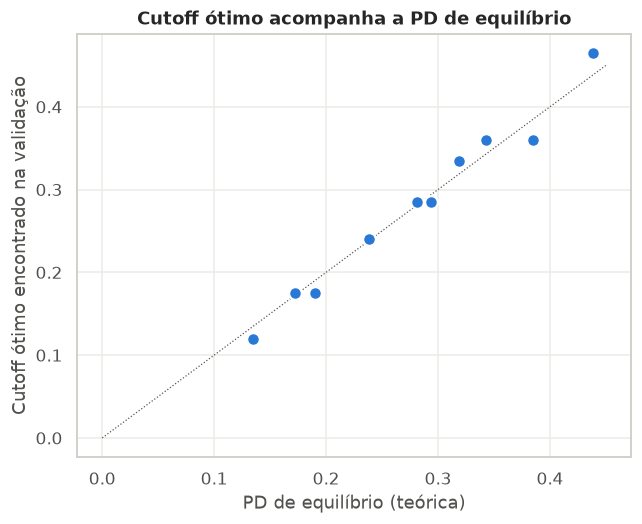

margem,LGD,PD equilíbrio,cutoff ótimo,aprovação,"ganho vs 0,50 (por 10 mil propostas)"
10%,40%,0.238,0.240,92.6%,R$ 232.800
10%,60%,0.172,0.175,90.1%,R$ 590.133
10%,80%,0.135,0.120,86.0%,R$ 1.017.689
15%,40%,0.319,0.335,95.0%,R$ 113.956
15%,60%,0.238,0.240,92.6%,R$ 349.200
15%,80%,0.190,0.175,90.1%,R$ 699.956
20%,40%,0.385,0.360,95.5%,R$ 53.511
20%,60%,0.294,0.285,93.8%,R$ 216.711
20%,80%,0.238,0.240,92.6%,R$ 465.600
25%,40%,0.439,0.465,97.2%,R$ 15.689


In [6]:
rows = []
for margin in [0.10, 0.15, 0.20, 0.25]:
    for lgd in [0.40, 0.60, 0.80]:
        a = ProfitAssumptions(margin_rate=margin, lgd=lgd)
        curve = profit_curve(y_val, p_gbm, a)
        best = optimal(curve)
        rows.append({
            "margem": f"{margin:.0%}", "LGD": f"{lgd:.0%}",
            "PD equilíbrio": a.breakeven_pd, "cutoff ótimo": best["cutoff"],
            "aprovação": best["aprovação"],
            "ganho vs 0,50 (por 10 mil propostas)": (best["lucro"] - simulate(y_val, p_gbm, 0.5, a)["lucro"]) * per_10k,
        })
sensitivity = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot([0, 0.45], [0, 0.45], color=GRAY, lw=0.8, ls=":")
ax.scatter(sensitivity["PD equilíbrio"], sensitivity["cutoff ótimo"], s=70, color=BLUE, edgecolor="white", lw=1.5, zorder=3)
ax.set_xlabel("PD de equilíbrio (teórica)")
ax.set_ylabel("Cutoff ótimo encontrado na validação")
ax.set_title("Cutoff ótimo acompanha a PD de equilíbrio")
savefig(fig, "cutoff_sensitivity")
plt.show()

sensitivity.style.format({"PD equilíbrio": "{:.3f}", "cutoff ótimo": "{:.3f}", "aprovação": "{:.1%}",
                          "ganho vs 0,50 (por 10 mil propostas)": brl}).hide(axis="index")

Duas conclusões. Primeiro, em todos os cenários o cutoff ótimo fica próximo da PD de equilíbrio. As pequenas diferenças vêm do ruído de uma amostra finita e de a curva de lucro ser bem plana perto do máximo. Então, na prática, a cooperativa nem precisa refazer a simulação toda vez que as condições mudam: ganho ÷ (ganho + perda) com as premissas novas já dá um ótimo ponto de partida.

Segundo, o 0,50 perde dinheiro em todos os cenários, mas o tamanho da perda varia muito. Quanto maior a margem e menor a perda em caso de default, mais a PD de equilíbrio se aproxima de 0,50 e menor fica a diferença. Com margem de 25% e LGD de 40%, o ganho de ajustar o cutoff é pequeno. Com margem baixa e LGD alta, que é o cenário mais comum em crédito sem garantia, ajustar o cutoff vale muito.

## 5. O cutoff em pontos de score

Para a área de crédito é mais natural falar em "score mínimo" do que em probabilidade. Usando a mesma escala do scorecard (600 pontos = chance 50:1, PDO 20), a PD do cutoff vira um score.

In [7]:
min_score = float(proba_to_score(best_gbm["cutoff"]))
print(f"cutoff {best_gbm['cutoff']:.3f} de probabilidade  ≈  score mínimo de {min_score:.0f} pontos")

cutoff 0.240 de probabilidade  ≈  score mínimo de 520 pontos


## 6. Salvando

Os números desta simulação vão para `reports/metrics.json`. É de lá que o README vai tirar a frase de destaque do projeto.

In [8]:
update_metrics("cutoff", {
    "set": "val",
    "assumptions": {"ticket": assumptions.ticket, "margin_rate": assumptions.margin_rate,
                    "ead_rate": assumptions.ead_rate, "lgd": assumptions.lgd,
                    "breakeven_pd": round(assumptions.breakeven_pd, 4)},
    "optimal_cutoff": float(best_gbm["cutoff"]),
    "optimal_min_score": round(min_score),
    "near_optimal_range": [float(near_best.min()), float(near_best.max())],
    "policies": {
        name: {k: (round(float(v), 4) if isinstance(v, (float, np.floating)) else int(v)) for k, v in row.items()}
        for name, row in {"approve_all": approve_all, "cutoff_050": naive, "optimal_lightgbm": best_gbm.to_dict(),
                          "optimal_scorecard": policies.loc["cutoff ótimo · scorecard"].to_dict()}.items()
    },
    "losses_avoided_vs_050": round(float(losses_avoided), 2),
    "margin_lost_vs_050": round(float(margin_lost), 2),
    "profit_gain_vs_050": round(float(profit_gain), 2),
    "profit_gain_vs_050_per_10k": round(float(profit_gain * per_10k), 2),
})["cutoff"]["optimal_cutoff"]

0.24